Dataset loaded! Shape: (100000, 7)
Columns after dropping IDs: ['Amount', 'MerchantID', 'TransactionType', 'Location', 'IsFraud']

Encoding categorical columns: ['TransactionType', 'Location']
All columns are now numeric ✅

Duplicate rows: 0

Class Distribution:
IsFraud
0    99000
1     1000
Name: count, dtype: int64
Fraud %: 1.00%


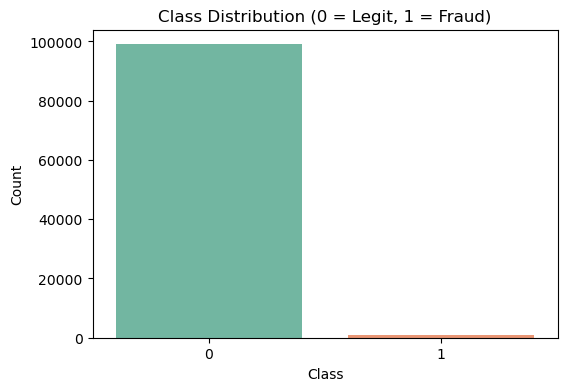

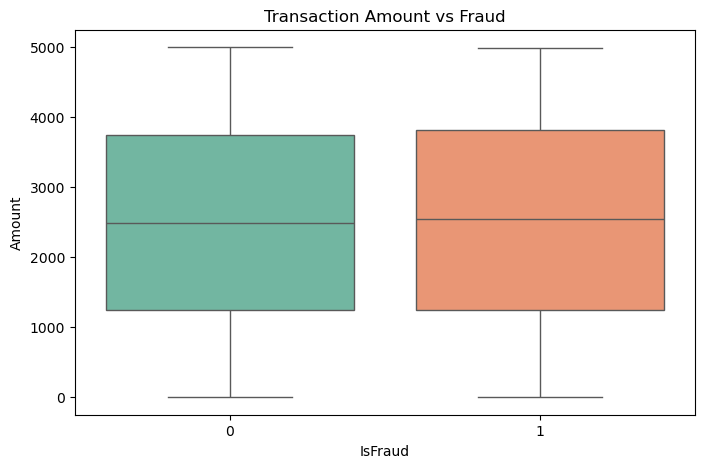

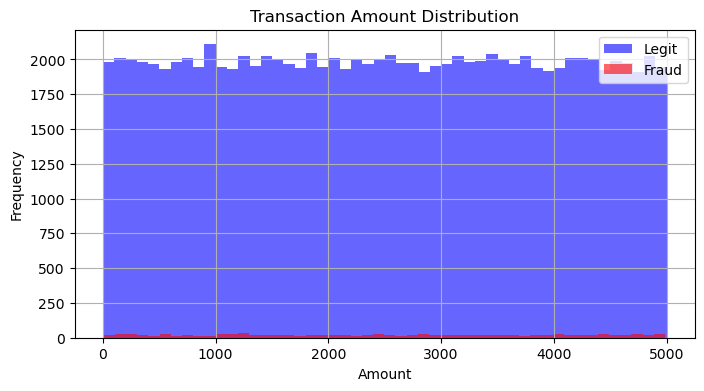

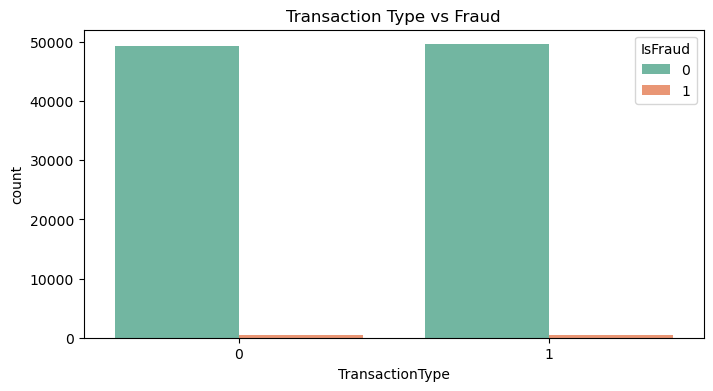

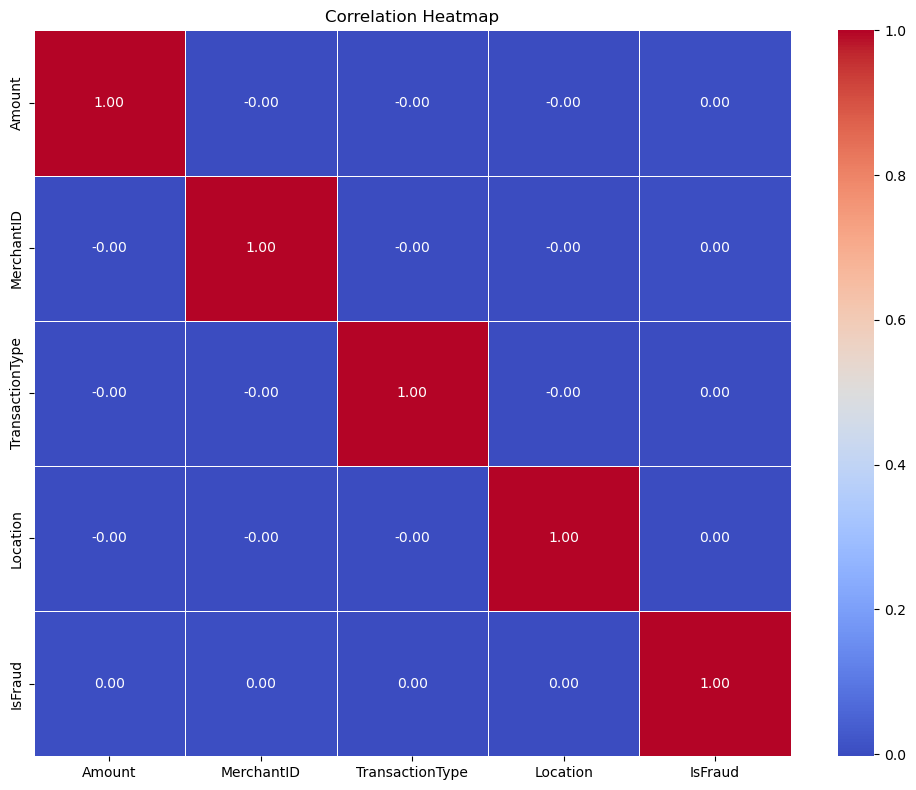

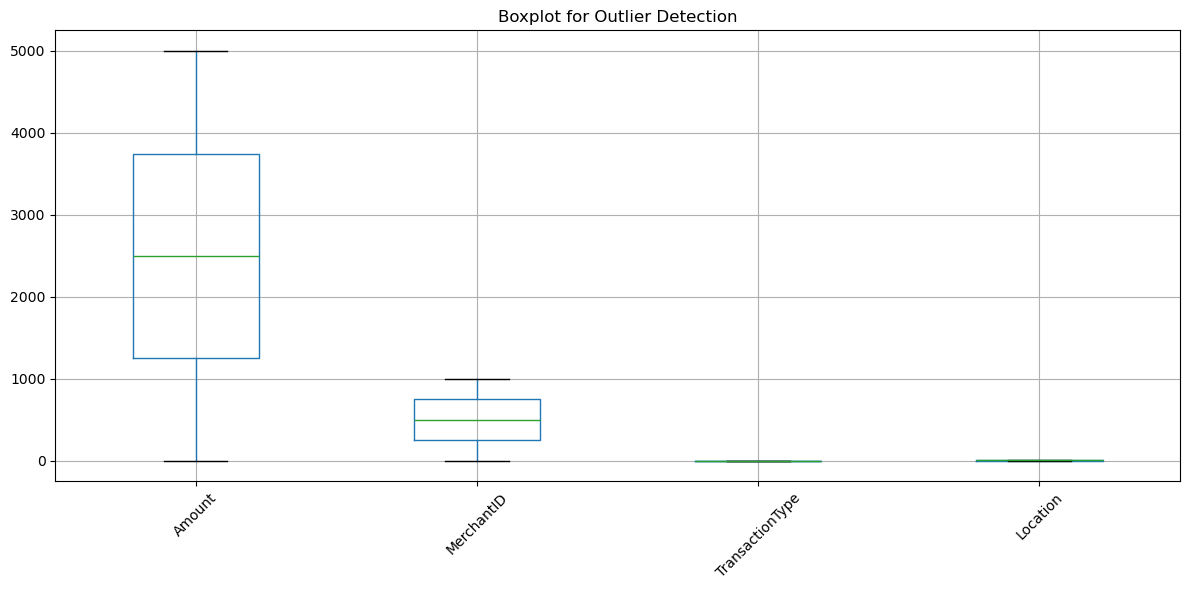

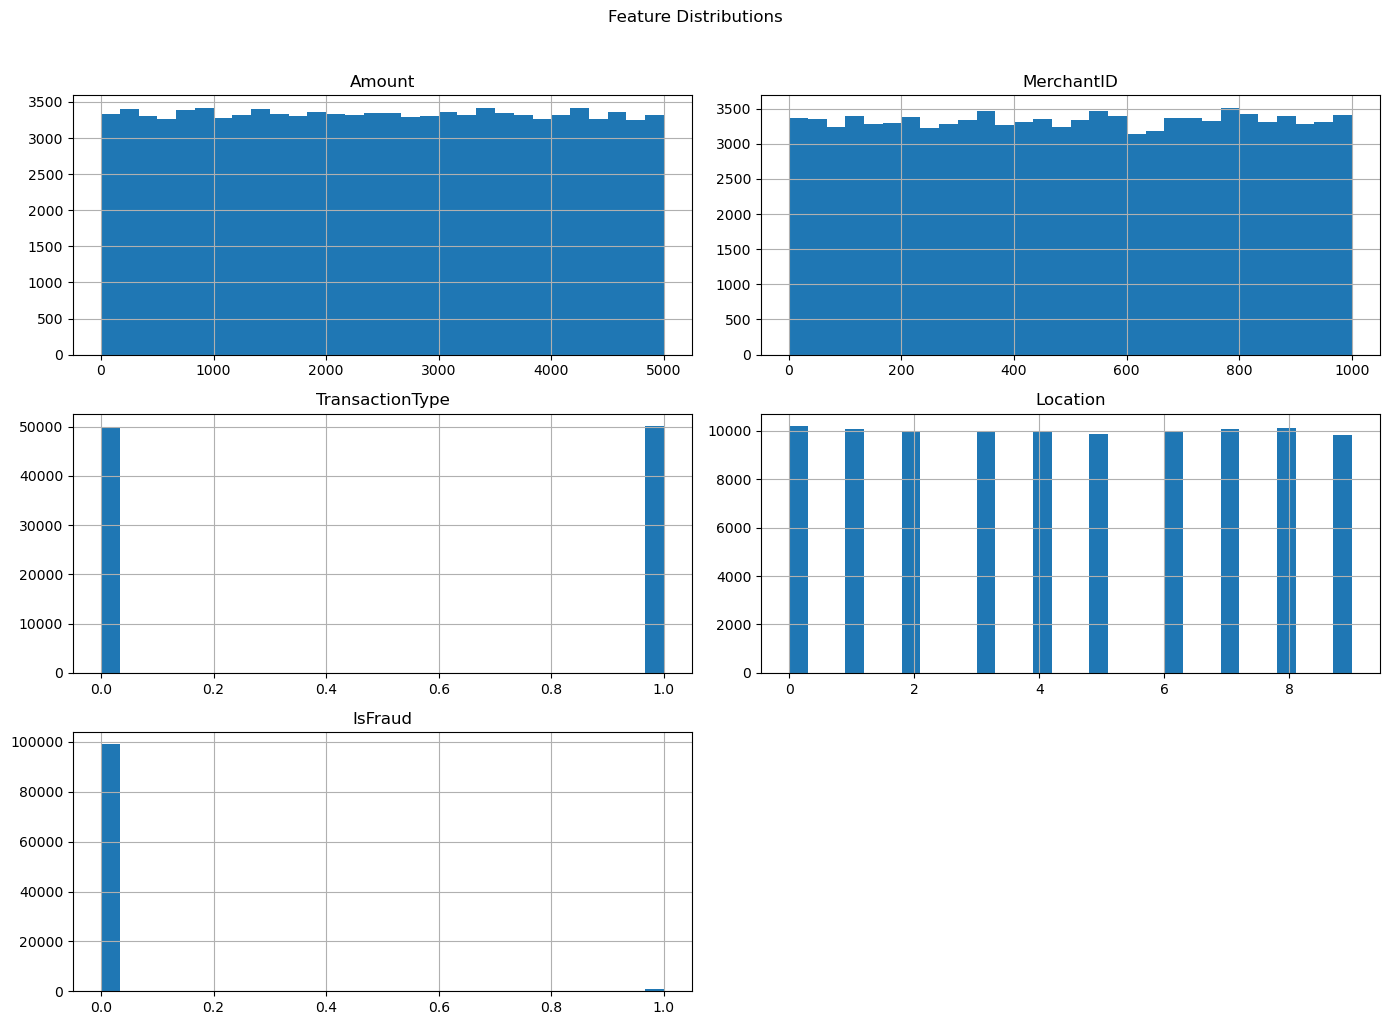


Training set: {0: 79200, 1: 800}
Test set: {0: 19800, 1: 200}

After SMOTE:
{0: 79200, 1: 79200}

Class weight ratio (Legit:Fraud) = 1:1

Random Forest Accuracy: 0.87805

Classification Report:
              precision    recall  f1-score   support

       Legit       0.99      0.89      0.93     19800
       Fraud       0.01      0.12      0.02       200

    accuracy                           0.88     20000
   macro avg       0.50      0.51      0.48     20000
weighted avg       0.98      0.88      0.93     20000



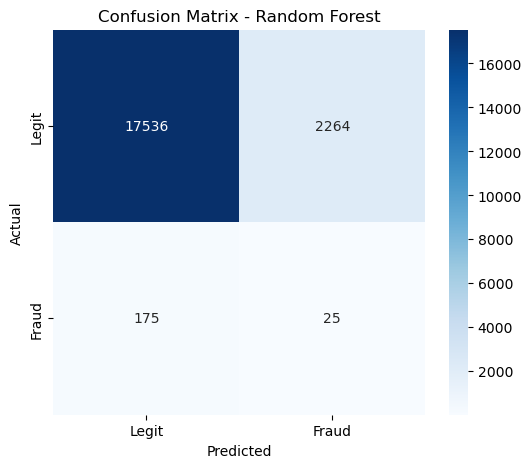

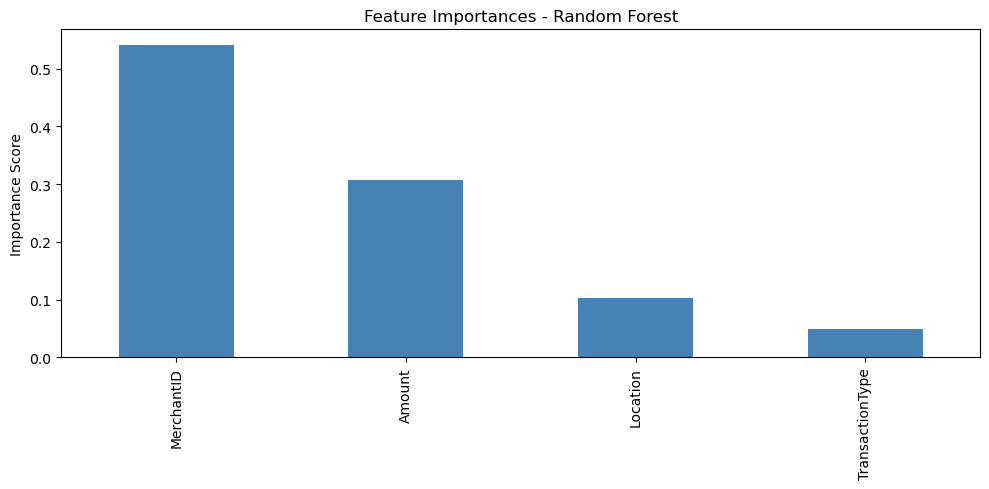


Model saved successfully!

Sample Prediction: Legit
Actual Label:      Legit

Random Forest ROC-AUC Score: 0.512761994949495


<Figure size 800x600 with 0 Axes>

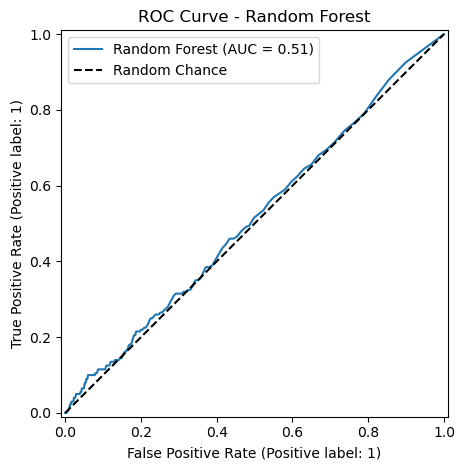

c:\Users\Sakshi\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:16:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Model Trained ✅

XGBoost Accuracy: 0.43155

XGBoost Classification Report (threshold=0.3):
              precision    recall  f1-score   support

       Legit       0.99      0.43      0.60     19800
       Fraud       0.01      0.60      0.02       200

    accuracy                           0.43     20000
   macro avg       0.50      0.51      0.31     20000
weighted avg       0.98      0.43      0.59     20000


XGBoost ROC-AUC Score: 0.5193412878787879


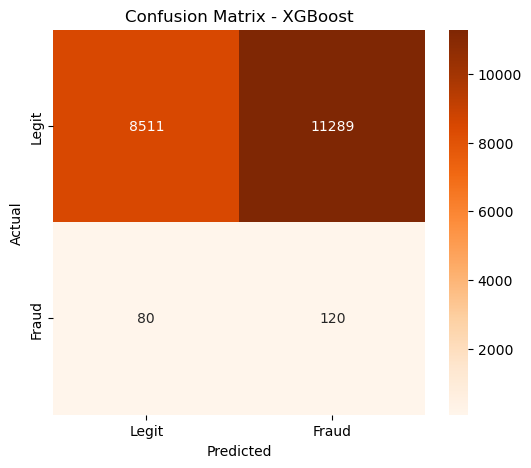

<Figure size 800x600 with 0 Axes>

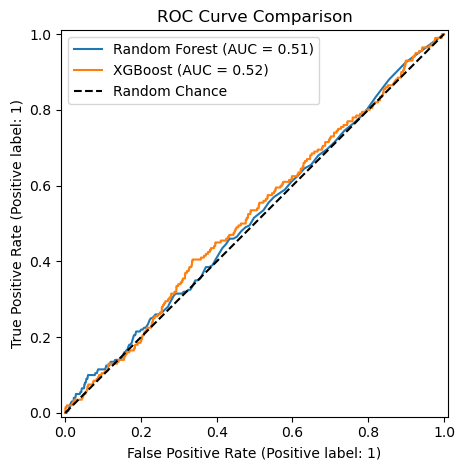

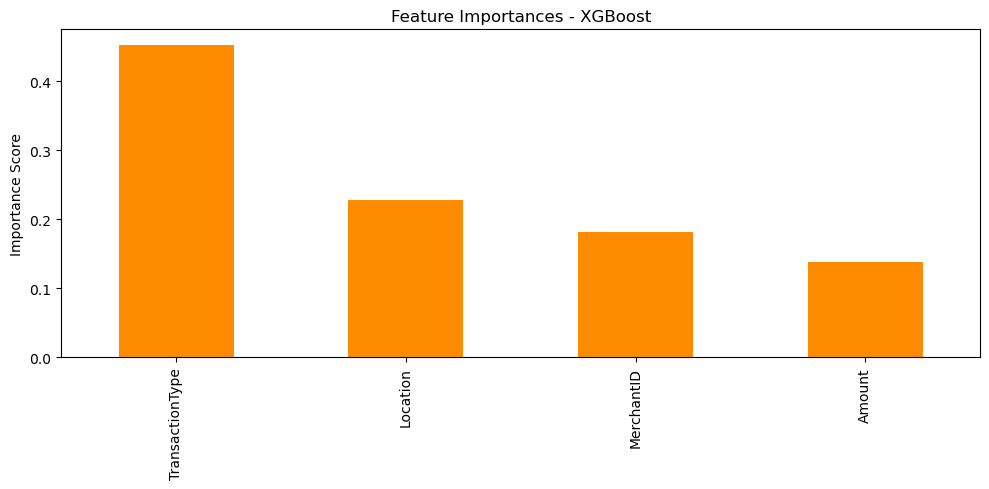

c:\Users\Sakshi\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:16:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✅ Pipeline Created & Trained (XGBoost)

✅ Full system saved (model + scaler + encoders + pipeline)

🔹 New Transaction Prediction: Legit


--- Running Optimized Final XGBoost Model ---

--- Final XGBoost Results (Threshold: 0.25) ---
              precision    recall  f1-score   support

           0       0.99      0.16      0.28     19800
           1       0.01      0.85      0.02       200

    accuracy                           0.17     20000
   macro avg       0.50      0.50      0.15     20000
weighted avg       0.98      0.17      0.27     20000

Area Under Precision-Recall Curve: 0.0101
ROC-AUC Score: 0.4915


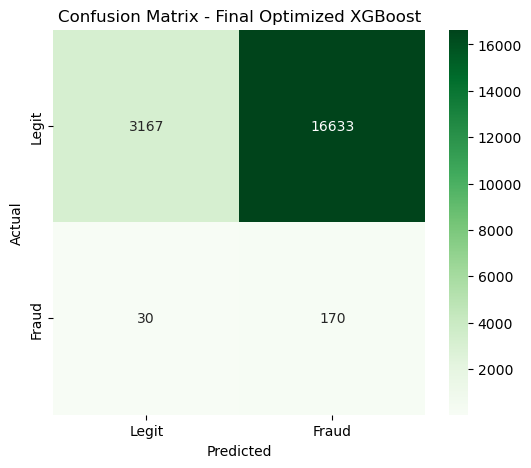

<Figure size 800x600 with 0 Axes>

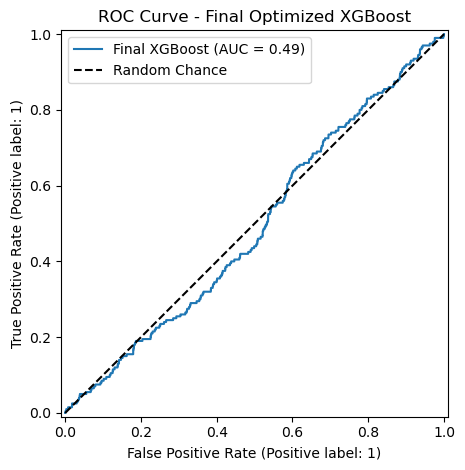


✅ Final optimized model saved: final_fraud_model.joblib


In [7]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import pickle
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score,
                              RocCurveDisplay, average_precision_score)
from imblearn.over_sampling import SMOTE

# ─────────────────────────────────────────────
# 1. LOAD DATASET
# ─────────────────────────────────────────────
df = pd.read_csv(r'C:\Users\Sakshi\Documents\credit_card_fraud_dataset.csv')
print("Dataset loaded! Shape:", df.shape)

# ─────────────────────────────────────────────
# 2. DROP USELESS COLUMNS (IDs & timestamps only)
# ─────────────────────────────────────────────
drop_cols = ['TransactionID', 'TransactionDate']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])
print("Columns after dropping IDs:", df.columns.tolist())

# ─────────────────────────────────────────────
# 3. ENCODE CATEGORICAL COLUMNS
#    (TransactionType, Location → numbers)
# ─────────────────────────────────────────────
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"\nEncoding categorical columns: {cat_cols}")

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

joblib.dump(encoders, "encoders.joblib")

print("All columns are now numeric ✅")

# ─────────────────────────────────────────────
# 4. MISSING VALUES
# ─────────────────────────────────────────────
df = df.fillna(df.median(numeric_only=True))

# ─────────────────────────────────────────────
# 5. DUPLICATE CHECK
# ─────────────────────────────────────────────
print("\nDuplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

# ─────────────────────────────────────────────
# 6. TARGET COLUMN
# ─────────────────────────────────────────────
target_col = 'IsFraud'
print(f"\nClass Distribution:")
print(df[target_col].value_counts())
print(f"Fraud %: {df[target_col].mean() * 100:.2f}%")

# ─────────────────────────────────────────────
# 7. EDA - VISUALIZATIONS
# ─────────────────────────────────────────────

# Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=target_col, data=df, hue=target_col, palette='Set2', legend=False)
plt.title("Class Distribution (0 = Legit, 1 = Fraud)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Amount by Class
plt.figure(figsize=(8, 5))
sns.boxplot(x=target_col, y='Amount', data=df, hue=target_col, palette='Set2', legend=False)
plt.title("Transaction Amount vs Fraud")
plt.show()

# Amount distribution overlay
plt.figure(figsize=(8, 4))
df[df[target_col] == 0]['Amount'].hist(bins=50, alpha=0.6, label='Legit', color='blue')
df[df[target_col] == 1]['Amount'].hist(bins=50, alpha=0.6, label='Fraud', color='red')
plt.legend()
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

# TransactionType vs Fraud
plt.figure(figsize=(8, 4))
sns.countplot(x='TransactionType', hue=target_col, data=df, palette='Set2')
plt.title("Transaction Type vs Fraud")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Boxplot for Outlier Detection
plt.figure(figsize=(12, 6))
df.drop(columns=[target_col]).boxplot()
plt.title("Boxplot for Outlier Detection")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Histograms
df.hist(figsize=(14, 10), bins=30)
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 8. FEATURE ENGINEERING & SCALING
# ─────────────────────────────────────────────
X = df.drop(target_col, axis=1)
y = df[target_col]

scaler = StandardScaler()
X[['Amount']] = scaler.fit_transform(X[['Amount']])

# ─────────────────────────────────────────────
# 9. TRAIN-TEST SPLIT
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTraining set:", y_train.value_counts().to_dict())
print("Test set:", y_test.value_counts().to_dict())

# ─────────────────────────────────────────────
# 9.5 SMOTE — oversample fraud in training set
#     ✅ After split so test data stays untouched
# ─────────────────────────────────────────────
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(y_train.value_counts().to_dict())

# ─────────────────────────────────────────────
# 10. TRAIN RANDOM FOREST
# ─────────────────────────────────────────────
fraud_ratio = int((y_train == 0).sum() / (y_train == 1).sum())
print(f"\nClass weight ratio (Legit:Fraud) = {fraud_ratio}:1")

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight={0: 1, 1: fraud_ratio}
)
rf.fit(X_train, y_train)

# ─────────────────────────────────────────────
# 11. EVALUATION — RANDOM FOREST
# ─────────────────────────────────────────────
y_pred = rf.predict(X_test)

print("\nRandom Forest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                             target_names=['Legit', 'Fraud'],
                             zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='steelblue')
plt.title("Feature Importances - Random Forest")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 12. SAVE MODEL & SCALER
# ─────────────────────────────────────────────
joblib.dump(rf, "random_forest_fraud_model.joblib")
joblib.dump(scaler, "scaler_fraud.joblib")

with open("random_forest_fraud_model.pkl", "wb") as f:
    pickle.dump(rf, f)

print("\nModel saved successfully!")

# ─────────────────────────────────────────────
# 13. PREDICT ON A NEW TRANSACTION
# ─────────────────────────────────────────────
model = joblib.load("random_forest_fraud_model.joblib")

sample = X_test.iloc[[0]]
prediction = model.predict(sample)
actual = y_test.iloc[0]

print(f"\nSample Prediction: {'Fraud' if prediction[0] == 1 else 'Legit'}")
print(f"Actual Label:      {'Fraud' if actual == 1 else 'Legit'}")

# ─────────────────────────────────────────────
# 14. ROC-AUC SCORE — RANDOM FOREST
# ─────────────────────────────────────────────
y_prob_rf = rf.predict_proba(X_test)[:, 1]
print("\nRandom Forest ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="Random Forest")
plt.title("ROC Curve - Random Forest")
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.legend()
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 14.5 XGBOOST MODEL — better for imbalanced data
# ─────────────────────────────────────────────
fraud_ratio_xgb = int((y_train == 0).sum() / (y_train == 1).sum())

xgb = XGBClassifier(
    n_estimators=300,
    scale_pos_weight=fraud_ratio_xgb,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr',
    use_label_encoder=False
)
xgb.fit(X_train, y_train)
print("\nXGBoost Model Trained ✅")

# XGBoost Evaluation
y_pred_xgb  = xgb.predict(X_test)
y_prob_xgb  = xgb.predict_proba(X_test)[:, 1]

# Lower threshold to 0.3 to catch more fraud
y_pred_xgb_thresh = (y_prob_xgb >= 0.3).astype(int)

print("\nXGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb_thresh))
print("\nXGBoost Classification Report (threshold=0.3):")
print(classification_report(y_test, y_pred_xgb_thresh,
                             target_names=['Legit', 'Fraud'],
                             zero_division=0))

print("\nXGBoost ROC-AUC Score:", roc_auc_score(y_test, y_prob_xgb))

# XGBoost Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb_thresh)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve Comparison
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_prob_rf,  name="Random Forest")
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, name="XGBoost", ax=plt.gca())
plt.title("ROC Curve Comparison")
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.legend()
plt.tight_layout()
plt.show()

# XGBoost Feature Importance
feat_imp_xgb = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
feat_imp_xgb.plot(kind='bar', color='darkorange')
plt.title("Feature Importances - XGBoost")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 15. CREATE PIPELINE (MODEL + SCALER)
#     Using XGBoost as the model
# ─────────────────────────────────────────────
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        n_estimators=200,
        scale_pos_weight=fraud_ratio_xgb,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        eval_metric='aucpr',
        use_label_encoder=False
    ))
])

pipeline.fit(X_train, y_train)

print("\n✅ Pipeline Created & Trained (XGBoost)")

# ─────────────────────────────────────────────
# 16. SAVE COMPLETE SYSTEM (IMPORTANT)
# ─────────────────────────────────────────────
joblib.dump({
    "model": xgb,
    "scaler": scaler,
    "pipeline": pipeline,
    "encoders": encoders,
    "features": X.columns.tolist()
}, "fraud_full_system.joblib")

with open("fraud_full_system.pkl", "wb") as f:
    pickle.dump({
        "model": xgb,
        "scaler": scaler,
        "pipeline": pipeline,
        "encoders": encoders,
        "features": X.columns.tolist()
    }, f)

print("\n✅ Full system saved (model + scaler + encoders + pipeline)")

# ─────────────────────────────────────────────
# 17. LOAD FULL SYSTEM (SAFE)
# ─────────────────────────────────────────────
loaded = joblib.load("fraud_full_system.joblib")

loaded_pipeline = loaded["pipeline"]
loaded_features = loaded["features"]

# ─────────────────────────────────────────────
# 18. SAFE REAL-WORLD PREDICTION
# ─────────────────────────────────────────────
new_sample = pd.DataFrame([X_test.iloc[0].values], columns=loaded_features)

pred = loaded_pipeline.predict(new_sample)

print("\n🔹 New Transaction Prediction:",
      "Fraud" if pred[0] == 1 else "Legit")

# ═════════════════════════════════════════════
# 19. IMPROVED FEATURE ENGINEERING
#     + OPTIMIZED XGBOOST (NO SMOTE)
#     Added from optimization block
# ═════════════════════════════════════════════
print("\n\n--- Running Optimized Final XGBoost Model ---")

# Reload fresh data for clean feature engineering
df2 = pd.read_csv(r'C:\Users\Sakshi\Documents\credit_card_fraud_dataset.csv')

# Fraud often involves unusual amounts compared to the average
avg_val = df2['Amount'].mean()
df2['Amount_to_Avg_Ratio'] = df2['Amount'] / avg_val

# Extract time-based features (Fraud often spikes at night or specific days)
df2['TransactionDate'] = pd.to_datetime(df2['TransactionDate'])
df2['Hour']      = df2['TransactionDate'].dt.hour
df2['DayOfWeek'] = df2['TransactionDate'].dt.dayofweek

# Drop raw IDs
df2 = df2.drop(columns=['TransactionID', 'TransactionDate'], errors='ignore')

# Encoding
encoders2 = {}
for col in df2.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df2[col] = le.fit_transform(df2[col].astype(str))
    encoders2[col] = le

# Train/Test Split
X2 = df2.drop('IsFraud', axis=1)
y2 = df2['IsFraud']
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, stratify=y2, random_state=42)

# Configure XGBoost for max recall — scale_pos_weight * 2
ratio2 = (y2_train == 0).sum() / (y2_train == 1).sum()

final_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=ratio2 * 2,   # penalize missed fraud even more
    eval_metric='aucpr',
    random_state=42
)
final_model.fit(X2_train, y2_train)

# Apply aggressive threshold of 0.1
y2_probs = final_model.predict_proba(X2_test)[:, 1]
custom_threshold = 0.25
y2_pred = (y2_probs >= custom_threshold).astype(int)

# Final Evaluation
print(f"\n--- Final XGBoost Results (Threshold: {custom_threshold}) ---")
print(classification_report(y2_test, y2_pred))
print(f"Area Under Precision-Recall Curve: {average_precision_score(y2_test, y2_probs):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y2_test, y2_probs):.4f}")

# Confusion Matrix
cm_final = confusion_matrix(y2_test, y2_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title("Confusion Matrix - Final Optimized XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y2_test, y2_probs, name="Final XGBoost")
plt.title("ROC Curve - Final Optimized XGBoost")
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.legend()
plt.tight_layout()
plt.show()

# Save final optimized model
joblib.dump({
    "model": final_model,
    "encoders": encoders2,
    "features": X2.columns.tolist()
}, "final_fraud_model.joblib")

print("\n✅ Final optimized model saved: final_fraud_model.joblib")

